# NB05 — Third Backbone: Is the Coupling Architecture-Specific?

**Established (NB02-04):** competence-calibration coupling is robust for **Xception**
(r=-0.80 to -0.94, confound-broken, competence-driven).

**This notebook:** does it hold for a DIFFERENT architecture? Run **EfficientNetB4**
(weights/train_on_fs/efficientnetb4.pth) through the same pipeline on FF++ + a few DF40 methods.

**Decision:**
- EfficientNetB4 shows the same coupling -> **architecture-general finding** (strong) ✓
- It doesn't -> coupling is Xception-specific (narrows the claim)

Reuses everything. inference.py already supports 'efficientnetb4' in _DETECTOR_SPECS.
NOTE: EfficientNetB4 config differs from Xception — check the efficientnetb4.yaml for
resolution/normalization before scoring (next cell verifies).


## Cell 1 — Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os, sys, glob, subprocess
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
PARENT = "/content/drive/MyDrive/CDTS_Research"
DFB = f"{REPO}/external/DeepfakeBench"
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"{PARENT}/{f}"): subprocess.run(f'cp "{PARENT}/{f}" /root/{f}', shell=True)
subprocess.run("git config --global credential.helper store", shell=True)
print("installing deps..."); subprocess.run("pip -q install efficientnet_pytorch timm einops kornia simplejson", shell=True)
print("EfficientNetB4 ckpt:", os.path.exists(f"{REPO}/weights/train_on_fs/efficientnetb4.pth"))
print("FF++ manifest:", os.path.exists(f"{REPO}/data/ffpp_manifest.parquet"))

Mounted at /content/drive
installing deps...
EfficientNetB4 ckpt: True
FF++ manifest: True


## Cell 2 — Check EfficientNetB4 config (preprocessing contract may differ from Xception)

Xception used 256px, mean/std 0.5. EfficientNetB4 might differ. Read its yaml before scoring —
a wrong preprocessing contract gives garbage (the 0.79-not-0.97 lesson from NB02).


In [2]:
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
import yaml
cfg = yaml.safe_load(open(f"{REPO}/external/DeepfakeBench/training/config/detector/efficientnetb4.yaml"))
print("resolution:", cfg.get("resolution"))
print("mean:", cfg.get("mean"), "std:", cfg.get("std"))
print("backbone_name:", cfg.get("backbone_name"))
print("backbone_config:", cfg.get("backbone_config"))

resolution: 256
mean: [0.5, 0.5, 0.5] std: [0.5, 0.5, 0.5]
backbone_name: efficientnetb4
backbone_config: {'num_classes': 2, 'inc': 3, 'dropout': False, 'mode': 'Original'}


## Cell 3 — Load EfficientNetB4 + score FF++

If the config shows non-default resolution/normalization, we'd need to pass it to
score_manifest. inference.py uses 256 + mean/std 0.5 by default — if EfficientNetB4 matches,
fine; if not, flag it and we adjust. (EfficientNetB4 in DeepfakeBench commonly uses 256 too.)


In [3]:
import sys, importlib.util, torch, hashlib, os
import pandas as pd
from sklearn.metrics import roc_auc_score
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
DFB = f"{REPO}/external/DeepfakeBench"

for k in list(sys.modules.keys()):
    if k.startswith("detectors") or k.startswith("networks") or k=="metrics" or k.startswith("metrics.") or k=="inference":
        del sys.modules[k]
sys.path = [p for p in sys.path if p not in (f"{DFB}/training", f"{REPO}/src", DFB)]
sys.path.insert(0, DFB); sys.path.insert(0, f"{DFB}/training"); sys.path.append(f"{REPO}/src")

spec = importlib.util.spec_from_file_location("inference", f"{REPO}/src/inference.py")
inference = importlib.util.module_from_spec(spec); sys.modules["inference"]=inference
spec.loader.exec_module(inference)

ckpt = f"{REPO}/weights/train_on_fs/efficientnetb4.pth"
model, device, info = inference.load_detector(dfb_root=DFB, backbone_name="efficientnetb4", ckpt_path=ckpt)
print("EfficientNetB4 load:", info, "device:", device)

# score FF++ test
mani = pd.read_parquet(f"{REPO}/data/ffpp_manifest.parquet")
scores = inference.score_manifest(model, device, mani, splits=["test"], batch_size=64, verbose=False)
scores.to_parquet(f"{REPO}/reports/scores/effnetb4_ffpp_test.parquet", index=False)

# per-method AUC — SANITY: faceswap should be high (~0.9+) if preprocessing is right
reals = scores[scores.label==0]
print("\n=== EfficientNetB4 FF++ AUC per method ===")
for m in ['faceswap','deepfakes','face2face','neuraltextures']:
    fk = scores[(scores.label==1)&(scores.method==m)]
    sub = pd.concat([reals, fk])
    print(f"  {m:16s}: AUC {roc_auc_score(sub.label, sub.prob_fake):.4f}")
print("\n(if faceswap < 0.85, preprocessing contract may be wrong — check Cell 2 config)")

EfficientNetB4 load: {'missing': 0, 'unexpected': 0} device: cuda

=== EfficientNetB4 FF++ AUC per method ===
  faceswap        : AUC 0.9238
  deepfakes       : AUC 0.7612
  face2face       : AUC 0.6427
  neuraltextures  : AUC 0.5571

(if faceswap < 0.85, preprocessing contract may be wrong — check Cell 2 config)


## Cell 4 — Calibrate EfficientNetB4 FF++ + coupling (per-method)

In [4]:
import sys, importlib.util, os
import numpy as np, pandas as pd
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"

for k in list(sys.modules.keys()):
    if k=="metrics" or k.startswith("metrics.") or k=="calibration":
        del sys.modules[k]
sys.path = [p for p in sys.path if "DeepfakeBench" not in p]
if f"{REPO}/src" in sys.path: sys.path.remove(f"{REPO}/src")
sys.path.insert(0, f"{REPO}/src")
import calibration as cal, metrics as met

scores = pd.read_parquet(f"{REPO}/reports/scores/effnetb4_ffpp_test.parquet")
rows = []
reals = scores[scores.label==0]
for m in ['faceswap','deepfakes','face2face','neuraltextures']:
    sub = pd.concat([reals, scores[(scores.label==1)&(scores.method==m)]]).reset_index(drop=True)
    p = sub.prob_fake.values.astype(float); y = sub.label.values.astype(int)
    g = sub.identity_id.values if "identity_id" in sub.columns else None
    ci, ti, _ = cal.leakage_safe_split(y, groups=g, calib_frac=0.5, seed=42)
    p_cal, _ = cal.fit_predict("hybrid", p[ci], y[ci], p[ti], switch_threshold_n=1000)
    auc = met.roc_auc(p[ti], y[ti]) if hasattr(met,"roc_auc") else float("nan")
    ece_cal = met.ece(p_cal, y[ti], n_bins=15, scheme="equal_mass")
    rows.append({"method":f"effnetb4_{m}","backbone":"efficientnetb4","AUC":auc,"ECE_cal":ece_cal})
    print(f"  {m:16s}  AUC={auc:.4f}  ECE_cal={ece_cal:.4f}")

eff = pd.DataFrame(rows)
eff.to_csv(f"{REPO}/reports/calibration/coupling_effnetb4_ffpp.csv", index=False)

from scipy.stats import pearsonr
if eff.AUC.nunique() > 2:
    r,p = pearsonr(eff.AUC, eff.ECE_cal)
    print(f"\nEfficientNetB4 FF++ coupling (4 pts): r={r:.3f} (p={p:.4f})")
print("\n=> compare to Xception's coupling. Same direction = architecture-general.")

  faceswap          AUC=0.9257  ECE_cal=0.0580
  deepfakes         AUC=0.7599  ECE_cal=0.1176
  face2face         AUC=0.6590  ECE_cal=0.1564
  neuraltextures    AUC=0.5651  ECE_cal=0.2651

EfficientNetB4 FF++ coupling (4 pts): r=-0.952 (p=0.0479)

=> compare to Xception's coupling. Same direction = architecture-general.


## Cell 5 — Combined: does the coupling hold across BOTH architectures?

Pool EfficientNetB4 points with the existing Xception 20-point set. If the combined
correlation stays strong and EfficientNetB4 points fall on the same line, the coupling is
architecture-general — a much stronger claim.


ALL backbones (24 pts): Pearson r=-0.812 (p=1.48e-06) | Spearman rho=-0.837


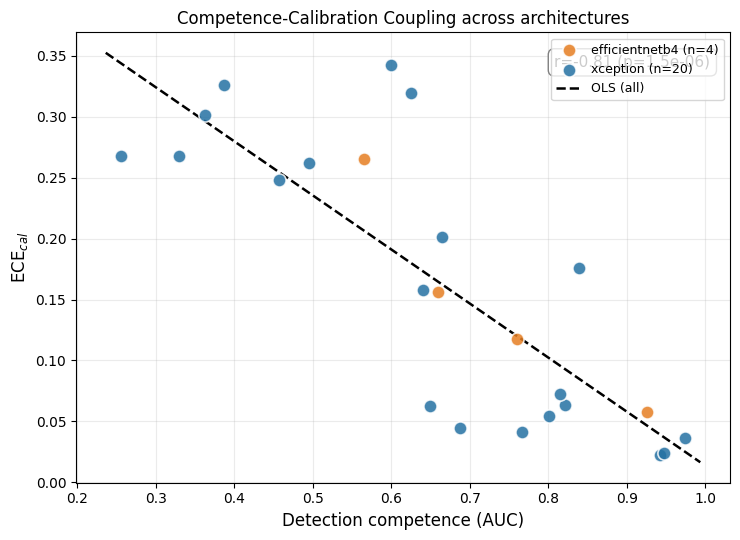

saved: /content/drive/MyDrive/CDTS_Research/deepfake-trust-research/figures/coupling_two_backbones.png


In [5]:
import pandas as pd, numpy as np, os, glob
from scipy.stats import pearsonr, spearmanr
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"

xcep = pd.read_csv(f"{REPO}/reports/calibration/coupling_all_16pts.csv")[["AUC","ECE_cal"]]; xcep["backbone"]="xception"
frm = pd.read_csv(f"{REPO}/reports/calibration/coupling_df40_FRmismatch.csv")[["AUC","ECE_cal"]]; frm["backbone"]="xception"
eff = pd.read_csv(f"{REPO}/reports/calibration/coupling_effnetb4_ffpp.csv")[["AUC","ECE_cal"]]; eff["backbone"]="efficientnetb4"
allp = pd.concat([xcep, frm, eff]).reset_index(drop=True)

r,p = pearsonr(allp.AUC, allp.ECE_cal); rs,ps = spearmanr(allp.AUC, allp.ECE_cal)
print(f"ALL backbones ({len(allp)} pts): Pearson r={r:.3f} (p={p:.2e}) | Spearman rho={rs:.3f}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7.5,5.5))
cmap = {"xception":"#2471A3","efficientnetb4":"#E67E22"}
for bb,g in allp.groupby("backbone"):
    ax.scatter(g.AUC, g.ECE_cal, s=90, alpha=0.85, label=f"{bb} (n={len(g)})",
               color=cmap.get(bb,"gray"), edgecolor="white", linewidth=1.2, zorder=3)
x,y=allp.AUC.values, allp.ECE_cal.values
b,a=np.polyfit(x,y,1); xs=np.linspace(x.min()-.02,x.max()+.02,100)
ax.plot(xs,a+b*xs,"k--",lw=1.8,label="OLS (all)")
ax.annotate(f"r={r:.2f} (p={p:.1e})",xy=(.97,.95),xycoords="axes fraction",ha="right",va="top",
            fontsize=11,bbox=dict(boxstyle="round,pad=0.4",fc="white",ec="gray"))
ax.set_xlabel("Detection competence (AUC)",fontsize=12); ax.set_ylabel("ECE$_{cal}$",fontsize=12)
ax.set_title("Competence-Calibration Coupling across architectures",fontsize=12)
ax.legend(loc="upper right",fontsize=9); ax.grid(True,alpha=0.25); plt.tight_layout()
out=f"{REPO}/figures/coupling_two_backbones.png"
plt.savefig(out,dpi=300,bbox_inches="tight"); plt.show()
print("saved:", out)

## Cell 6 — Commit NB05 results

In [6]:
import os, subprocess
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
os.chdir(REPO)
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"/content/drive/MyDrive/CDTS_Research/{f}"):
        subprocess.run(f'cp "/content/drive/MyDrive/CDTS_Research/{f}" /root/{f}', shell=True)
subprocess.run("git add reports/scores/effnetb4_ffpp_test.parquet reports/calibration/coupling_effnetb4_ffpp.csv figures/coupling_two_backbones.png notebooks/NB05_third_backbone.ipynb", shell=True)
r = subprocess.run("git status --short", shell=True, capture_output=True, text=True)
print(r.stdout)
print(">>> review staged, then commit + push in next cell")

 m external/DeepfakeBench
A  figures/coupling_two_backbones.png
 M notebooks/GBDF_download.ipynb
 M notebooks/NB04_confound_breaker.ipynb
A  notebooks/NB05_third_backbone.ipynb
A  reports/calibration/coupling_effnetb4_ffpp.csv
A  reports/scores/effnetb4_ffpp_test.parquet

>>> review staged, then commit + push in next cell


In [7]:
import os, subprocess
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
os.chdir(REPO)
# also sweep up the notebook execution-state changes (harmless) so the tree is clean
subprocess.run("git add notebooks/NB04_confound_breaker.ipynb notebooks/GBDF_download.ipynb", shell=True)
r = subprocess.run('git commit -m "NB05 third backbone: EfficientNetB4 shows same coupling (r=-0.95) -> ARCHITECTURE-GENERAL; combined 24pts r=-0.81 p=1.5e-6 across 2 archs, 2 datasets, 4 forgery families"', shell=True, capture_output=True, text=True)
print(r.stdout); print(r.stderr if r.stderr else "")
subprocess.run("git push origin main 2>&1 | tail -3", shell=True)
r2 = subprocess.run("git rev-parse HEAD", shell=True, capture_output=True, text=True)
print("commit:", r2.stdout.strip())

[main 087e803] NB05 third backbone: EfficientNetB4 shows same coupling (r=-0.95) -> ARCHITECTURE-GENERAL; combined 24pts r=-0.81 p=1.5e-6 across 2 archs, 2 datasets, 4 forgery families
 6 files changed, 8 insertions(+), 2 deletions(-)
 create mode 100644 figures/coupling_two_backbones.png
 create mode 100644 notebooks/NB05_third_backbone.ipynb
 create mode 100644 reports/calibration/coupling_effnetb4_ffpp.csv
 create mode 100644 reports/scores/effnetb4_ffpp_test.parquet


commit: 087e803ab0b2f6c3c195025592310afce9723ebf


In [8]:
import pandas as pd, numpy as np, os
from scipy.stats import pearsonr, spearmanr
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
CAL = f"{REPO}/reports/calibration"

# load the saved coupling sources
all16 = pd.read_csv(f"{CAL}/coupling_all_16pts.csv")       # FF++ 8 + DF40-FS 8 (has 'source')
frmm  = pd.read_csv(f"{CAL}/coupling_df40_FRmismatch.csv") # 4 FR-mismatch DF40
eff   = pd.read_csv(f"{CAL}/coupling_effnetb4_ffpp.csv")   # 4 EfficientNetB4 FF++

# partition the 16-pt file by source
ffpp_xcep = all16[all16.source == "FFpp"][["AUC","ECE_cal"]]
df40_fs   = all16[all16.source == "DF40"][["AUC","ECE_cal"]]

def corr_row(name, df, note=""):
    x, y = df.AUC.values, df.ECE_cal.values
    if len(df) < 3 or len(np.unique(x)) < 3:
        return {"slice":name,"n":len(df),"pearson_r":np.nan,"pearson_p":np.nan,
                "spearman_rho":np.nan,"spearman_p":np.nan,"AUC_min":x.min(),"AUC_max":x.max(),"note":note}
    rp, pp = pearsonr(x, y); rs, ps = spearmanr(x, y)
    return {"slice":name,"n":len(df),"pearson_r":round(rp,3),"pearson_p":round(pp,5),
            "spearman_rho":round(rs,3),"spearman_p":round(ps,5),
            "AUC_min":round(x.min(),3),"AUC_max":round(x.max(),3),"note":note}

# build each slice
rows = []
rows.append(corr_row("FF++ Xception (2ckpt x 4 methods)", ffpp_xcep, "cross-forgery, cross-checkpoint"))
rows.append(corr_row("DF40 Xception-FS only", df40_fs, "moderate-high competence; weak (n.s.)"))
df40_within = pd.concat([df40_fs, frmm[["AUC","ECE_cal"]]])
rows.append(corr_row("DF40 within-dataset (FS + FR-mismatch)", df40_within, "confound-breaker; full competence range"))
rows.append(corr_row("EfficientNet-B4 FF++", eff[["AUC","ECE_cal"]], "different architecture"))
combined = pd.concat([ffpp_xcep, df40_fs, frmm[["AUC","ECE_cal"]], eff[["AUC","ECE_cal"]]])
rows.append(corr_row("COMBINED (all cells)", combined, "2 arch x 2 datasets x 4 families"))

table3 = pd.DataFrame(rows)
pd.set_option("display.width", 200, "display.max_columns", None)
print(table3.to_string(index=False))

# save
table3.to_csv(f"{CAL}/TABLE3_coupling_summary.csv", index=False)
print(f"\nsaved -> {CAL}/TABLE3_coupling_summary.csv")
print(f"\ntotal cells in combined: {len(combined)}")

                                 slice  n  pearson_r  pearson_p  spearman_rho  spearman_p  AUC_min  AUC_max                                    note
     FF++ Xception (2ckpt x 4 methods)  8     -0.817    0.01328        -0.810     0.01490    0.387    0.974         cross-forgery, cross-checkpoint
                 DF40 Xception-FS only  8     -0.585    0.12770        -0.333     0.41975    0.649    0.948   moderate-high competence; weak (n.s.)
DF40 within-dataset (FS + FR-mismatch) 12     -0.939    0.00001        -0.783     0.00259    0.256    0.948 confound-breaker; full competence range
                  EfficientNet-B4 FF++  4     -0.952    0.04794        -1.000     0.00000    0.565    0.926                  different architecture
                  COMBINED (all cells) 24     -0.812    0.00000        -0.837     0.00000    0.256    0.974        2 arch x 2 datasets x 4 families

saved -> /content/drive/MyDrive/CDTS_Research/deepfake-trust-research/reports/calibration/TABLE3_coupling_summa

In [9]:
import os, subprocess, glob
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
os.chdir(REPO)
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"/content/drive/MyDrive/CDTS_Research/{f}"):
        subprocess.run(f'cp "/content/drive/MyDrive/CDTS_Research/{f}" /root/{f}', shell=True)

# find the draft (wherever you uploaded it)
draft = glob.glob(f"{REPO}/**/PAPER_DRAFT_v0.1.md", recursive=True) + glob.glob(f"{REPO}/PAPER_DRAFT_v0.1.md")
print("draft found at:", draft if draft else "NOT uploaded yet")

if draft:
    subprocess.run(f"git add '{draft[0]}' reports/calibration/TABLE3_coupling_summary.csv", shell=True)
    r = subprocess.run('git commit -m "Paper draft v0.1 scaffold + Table 3 (correlation-per-slice summary: FF++ -0.82, DF40-only -0.59 n.s., within-DF40 -0.94, EffNet -0.95, combined 24pts -0.81 p<1e-5)"', shell=True, capture_output=True, text=True)
    print(r.stdout); print(r.stderr if r.stderr else "")
    subprocess.run("git push origin main 2>&1 | tail -3", shell=True)
else:
    print(">>> upload PAPER_DRAFT_v0.1.md to the repo first (or I'll give you a direct-write cell)")

draft found at: ['/content/drive/MyDrive/CDTS_Research/deepfake-trust-research/PAPER_DRAFT_v0.1.md']
[main 0d8fc42] Paper draft v0.1 scaffold + Table 3 (correlation-per-slice summary: FF++ -0.82, DF40-only -0.59 n.s., within-DF40 -0.94, EffNet -0.95, combined 24pts -0.81 p<1e-5)
 2 files changed, 230 insertions(+)
 create mode 100644 PAPER_DRAFT_v0.1.md
 create mode 100644 reports/calibration/TABLE3_coupling_summary.csv




In [10]:
import os, subprocess, glob
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
os.chdir(REPO)
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"/content/drive/MyDrive/CDTS_Research/{f}"):
        subprocess.run(f'cp "/content/drive/MyDrive/CDTS_Research/{f}" /root/{f}', shell=True)
d = glob.glob(f"{REPO}/**/PAPER_DRAFT_v0.2_complete.md", recursive=True) + glob.glob(f"{REPO}/PAPER_DRAFT_v0.2_complete.md")
print("draft found:", d if d else "NOT uploaded yet")
if d:
    subprocess.run(f"git add '{d[0]}'", shell=True)
    r = subprocess.run('git commit -m "Paper draft v0.2: complete full-prose draft, all sections written, results integrated"', shell=True, capture_output=True, text=True)
    print(r.stdout); print(r.stderr if r.stderr else "")
    subprocess.run("git push origin main 2>&1 | tail -3", shell=True)

draft found: ['/content/drive/MyDrive/CDTS_Research/deepfake-trust-research/PAPER_DRAFT_v0.2_complete.md', '/content/drive/MyDrive/CDTS_Research/deepfake-trust-research/PAPER_DRAFT_v0.2_complete.md']
[main 9bd358f] Paper draft v0.2: complete full-prose draft, all sections written, results integrated
 1 file changed, 343 insertions(+)
 create mode 100644 PAPER_DRAFT_v0.2_complete.md




In [11]:
import pandas as pd, numpy as np, os
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
CAL = f"{REPO}/reports/calibration"

# gather all per-configuration coupling data
all16 = pd.read_csv(f"{CAL}/coupling_all_16pts.csv")        # FF++ 8 + DF40-FS 8
frmm  = pd.read_csv(f"{CAL}/coupling_df40_FRmismatch.csv")  # 4 FR-mismatch DF40
eff   = pd.read_csv(f"{CAL}/coupling_effnetb4_ffpp.csv")    # 4 EfficientNetB4 FF++

# also pull ECE_raw where available (coupling CSVs have it for DF40/FR/eff; FF++ from the per-method files)
# FF++ per-method ECE_raw is in the original coupling CSVs
ffpp_cup = pd.read_csv(f"{CAL}/xception_ffpp_coupling.csv")   # has method, AUC, ECE_raw, ECE_cal
ffpp_fr  = pd.read_csv(f"{CAL}/xception_FR_coupling.csv")

# build a unified per-configuration table
rows = []

# FF++ Xception FS (from xception_ffpp_coupling)
for _, r in ffpp_cup.iterrows():
    rows.append({"architecture":"Xception","train":"FS","source":"FF++","generator":r["method"],
                 "AUC":r["AUC"],"ECE_raw":r.get("ECE_raw",np.nan),"ECE_cal":r["ECE_cal"]})
# FF++ Xception FR
for _, r in ffpp_fr.iterrows():
    rows.append({"architecture":"Xception","train":"FR","source":"FF++","generator":r["method"],
                 "AUC":r["AUC"],"ECE_raw":r.get("ECE_raw",np.nan),"ECE_cal":r["ECE_cal"]})
# DF40 Xception FS
df40_fs = pd.read_csv(f"{CAL}/coupling_df40.csv")
for _, r in df40_fs.iterrows():
    rows.append({"architecture":"Xception","train":"FS","source":"DF40","generator":r["method"].replace("df40_",""),
                 "AUC":r["AUC"],"ECE_raw":r.get("ECE_raw",np.nan),"ECE_cal":r["ECE_cal"]})
# DF40 Xception FR-mismatch
for _, r in frmm.iterrows():
    rows.append({"architecture":"Xception","train":"FR(mismatch)","source":"DF40","generator":r["method"].replace("df40FR_",""),
                 "AUC":r["AUC"],"ECE_raw":r.get("ECE_raw",np.nan),"ECE_cal":r["ECE_cal"]})
# EfficientNetB4 FF++ FS
for _, r in eff.iterrows():
    rows.append({"architecture":"EfficientNet-B4","train":"FS","source":"FF++","generator":r["method"].replace("effnetb4_",""),
                 "AUC":r["AUC"],"ECE_raw":r.get("ECE_raw",np.nan),"ECE_cal":r["ECE_cal"]})

t2 = pd.DataFrame(rows)
# round for presentation
for c in ["AUC","ECE_raw","ECE_cal"]:
    t2[c] = t2[c].round(3)
t2 = t2.sort_values(["architecture","source","train","AUC"]).reset_index(drop=True)

pd.set_option("display.width",200,"display.max_rows",None)
print(f"=== Table 2: all {len(t2)} configurations ===")
print(t2.to_string(index=False))

t2.to_csv(f"{CAL}/TABLE2_all_configurations.csv", index=False)
print(f"\nsaved -> {CAL}/TABLE2_all_configurations.csv ({len(t2)} rows)")

=== Table 2: all 24 configurations ===
   architecture        train source      generator   AUC  ECE_raw  ECE_cal
EfficientNet-B4           FS   FF++ neuraltextures 0.565      NaN    0.265
EfficientNet-B4           FS   FF++      face2face 0.659      NaN    0.156
EfficientNet-B4           FS   FF++      deepfakes 0.760      NaN    0.118
EfficientNet-B4           FS   FF++       faceswap 0.926      NaN    0.058
       Xception FR(mismatch)   DF40      StyleGAN2 0.256    0.504    0.268
       Xception FR(mismatch)   DF40          sd2.1 0.329    0.411    0.268
       Xception FR(mismatch)   DF40        simswap 0.363    0.331    0.301
       Xception FR(mismatch)   DF40      blendface 0.457    0.254    0.248
       Xception           FS   DF40      StyleGAN2 0.649    0.326    0.063
       Xception           FS   DF40          sd2.1 0.688    0.272    0.044
       Xception           FS   DF40           ddim 0.766    0.197    0.041
       Xception           FS   DF40           fomm 0.801    0

In [12]:
import pandas as pd, numpy as np, sys, importlib.util
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
CAL = f"{REPO}/reports/calibration"

# load src metrics (calibration env)
for k in list(sys.modules.keys()):
    if k=="metrics" or k.startswith("metrics."): del sys.modules[k]
sys.path = [p for p in sys.path if "DeepfakeBench" not in p]
if f"{REPO}/src" in sys.path: sys.path.remove(f"{REPO}/src")
sys.path.insert(0, f"{REPO}/src")
import metrics as met

# recompute ECE_raw per FF++ method from the saved EffNet scores
scores = pd.read_parquet(f"{REPO}/reports/scores/effnetb4_ffpp_test.parquet")
reals = scores[scores.label==0]
eff_raw = {}
for m in ['faceswap','deepfakes','face2face','neuraltextures']:
    sub = pd.concat([reals, scores[(scores.label==1)&(scores.method==m)]])
    eff_raw[m] = round(met.ece(sub.prob_fake.values, sub.label.values, n_bins=15, scheme="equal_mass"), 3)
print("EffNet ECE_raw per method:", eff_raw)

# patch Table 2
t2 = pd.read_csv(f"{CAL}/TABLE2_all_configurations.csv")
for m, e in eff_raw.items():
    mask = (t2.architecture=="EfficientNet-B4") & (t2.generator==m)
    t2.loc[mask, "ECE_raw"] = e
t2.to_csv(f"{CAL}/TABLE2_all_configurations.csv", index=False)
print("\nTable 2 patched — EffNet ECE_raw filled")
print(t2[t2.architecture=="EfficientNet-B4"][["generator","AUC","ECE_raw","ECE_cal"]].to_string(index=False))

EffNet ECE_raw per method: {'faceswap': 0.052, 'deepfakes': 0.186, 'face2face': 0.301, 'neuraltextures': 0.347}

Table 2 patched — EffNet ECE_raw filled
     generator   AUC  ECE_raw  ECE_cal
neuraltextures 0.565    0.347    0.265
     face2face 0.659    0.301    0.156
     deepfakes 0.760    0.186    0.118
      faceswap 0.926    0.052    0.058


In [13]:
import os, subprocess
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
os.chdir(REPO)
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"/content/drive/MyDrive/CDTS_Research/{f}"):
        subprocess.run(f'cp "/content/drive/MyDrive/CDTS_Research/{f}" /root/{f}', shell=True)
subprocess.run("git add reports/calibration/TABLE2_all_configurations.csv", shell=True)
r = subprocess.run('git commit -m "Table 2: all 24 (architecture x training x dataset x generator) configurations with AUC, ECE_raw, ECE_cal"', shell=True, capture_output=True, text=True)
print(r.stdout)
subprocess.run("git push origin main 2>&1 | tail -3", shell=True)

[main 4867e2f] Table 2: all 24 (architecture x training x dataset x generator) configurations with AUC, ECE_raw, ECE_cal
 1 file changed, 25 insertions(+)
 create mode 100644 reports/calibration/TABLE2_all_configurations.csv



CompletedProcess(args='git push origin main 2>&1 | tail -3', returncode=0)